In [1]:
!pip install datasets huggingface_hub pandas numpy scikit-learn matplotlib seaborn
!pip install shap lime-tabular

ERROR: Could not find a version that satisfies the requirement lime-tabular (from versions: none)
ERROR: No matching distribution found for lime-tabular


In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from huggingface_hub import list_repo_files

print(" Exploring actual MLOmics file structure...")
files = list_repo_files("AIBIC/MLOmics", repo_type="dataset")

brca_files = [f for f in files if 'BRCA' in f and 'mRNA' in f]
print("Available BRCA mRNA files:")
for file in brca_files:
    print(f"  - {file}")

# look for any CSV files in the GS-BRCA directory
gs_brca_files = [f for f in files if 'GS-BRCA' in f]
print(f"\nAll GS-BRCA files ({len(gs_brca_files)} found):")
for file in gs_brca_files[:10]:  # Show first 10
    print(f"  - {file}")



 Exploring actual MLOmics file structure...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Available BRCA mRNA files:
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_mRNA_aligned.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Original/BRCA_mRNA.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_mRNA_top.csv
  - Main_Dataset/Imputation_datasets/Imp-BRCA/Top/BRCA_mRNA.csv

All GS-BRCA files (15 found):
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_CNV_aligned.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_Methy_aligned.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_label_num.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_mRNA_aligned.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Aligned/BRCA_miRNA_aligned.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Original/BRCA_CNV.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Original/BRCA_Methy.csv
  - Main_Dataset/Classification_datasets/GS-BRCA/Original/BRCA_label_num.csv
  - Main_Dataset/Classification_datasets/G

# Initial Model
  1. BRCA (breast cancer)

  2. COAD (colon cancer)

  3. GBM (brain cancer)

  4. LUAD (lung cancer)

     Each cancer type had:

      1. mRNA expression data

      2. CNV (copy number variation) data

      3. DNA methylation data
   
  Why:
Using multi-omics improves prediction accuracy because different genomic layers capture complementary biology. For example:

mRNA → gene activity level

CNV → structural DNA changes

Methylation → epigenetic regulation



Iska Matlab we had 32 Cancer Types, for testing our model we took 4 cancer types with highest patients so total sample size is approx 1600+ for the initial testing


In [4]:
#ham sirf top features use karenge since every omic layer has thousands and lakhs of features which might not be feasible for us
try:
    print("Downloading BRCA mRNA Top features...")
    file_path = hf_hub_download(
        repo_id="AIBIC/MLOmics",
        filename="Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_mRNA_top.csv",
        repo_type="dataset"
    )

    # Load the data
    brca_mrna = pd.read_csv(file_path)
    print(f" Successfully loaded BRCA mRNA Top features: {brca_mrna.shape}")

    # Also download the labels
    label_path = hf_hub_download(
        repo_id="AIBIC/MLOmics",
        filename="Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_label_num.csv",
        repo_type="dataset"
    )

    brca_labels = pd.read_csv(label_path)
    print(f" Successfully loaded BRCA labels: {brca_labels.shape}")

except Exception as e:
    print(f"Error: {e}")



BRCA_mRNA_top.csv:   0%|          | 0.00/61.3M [00:00<?, ?B/s]

 Successfully loaded BRCA mRNA Top features: (5000, 672)


BRCA_label_num.csv:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

 Successfully loaded BRCA labels: (671, 1)


In [5]:
# Explore your loaded data
def explore_brca_files(mrna_data, label_data):
    print(" BRCA mRNA Data Structure:")
    print(f"  Shape: {mrna_data.shape}")
    print(f"  Columns (first 5): {list(mrna_data.columns[:5])}")
    print(f"  Data type: {mrna_data.dtypes[1]}")  # Check if it's numeric

    print("\nBRCA Label Data Structure:")
    print(f"  Shape: {label_data.shape}")
    print(f"  Columns: {list(label_data.columns)}")

    # Check label distribution
    if len(label_data.columns) > 1:
        label_col = label_data.columns[1]  # Usually second column
        print(f"  Label distribution: {label_data[label_col].value_counts()}")

    # Check if patient IDs match
    if 'sample_id' in mrna_data.columns or mrna_data.columns[0].startswith('TCGA'):
        mrna_ids = set(mrna_data.iloc[:, 0])  # First column usually has IDs
        label_ids = set(label_data.iloc[:, 0])
        overlap = len(mrna_ids.intersection(label_ids))
        print(f"\n Patient ID overlap: {overlap} samples")

    return mrna_data, label_data

# Run exploration
if 'brca_mrna' in locals() and 'brca_labels' in locals():
    brca_mrna, brca_labels = explore_brca_files(brca_mrna, brca_labels)


 BRCA mRNA Data Structure:
  Shape: (5000, 672)
  Columns (first 5): ['Unnamed: 0', 'TCGA.3C.AAAU.01', 'TCGA.3C.AALI.01', 'TCGA.3C.AALJ.01', 'TCGA.3C.AALK.01']
  Data type: float64

BRCA Label Data Structure:
  Shape: (671, 1)
  Columns: ['Label']


/tmp/ipython-input-2733390282.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Data type: {mrna_data.dtypes[1]}")  # Check if it's numeric


In [6]:
# Download all BRCA omics data (Top features)
omics_files = {
    'mRNA': 'Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_mRNA_top.csv',
    'miRNA': 'Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_miRNA_top.csv',
    'CNV': 'Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_CNV_top.csv',
    'Methylation': 'Main_Dataset/Classification_datasets/GS-BRCA/Top/BRCA_Methy_top.csv'
}

brca_omics = {}

for omics_type, file_path in omics_files.items():
    try:
        print(f"Downloading BRCA {omics_type}...")
        local_path = hf_hub_download(
            repo_id="AIBIC/MLOmics",
            filename=file_path,
            repo_type="dataset"
        )

        data = pd.read_csv(local_path)
        brca_omics[omics_type] = data
        print(f" {omics_type}: {data.shape}")

    except Exception as e:
        print(f" Failed to download {omics_type}: {e}")

print(f"\n Successfully loaded {len(brca_omics)} omics types for BRCA")


 mRNA: (5000, 672)


BRCA_miRNA_top.csv:   0%|          | 0.00/1.79M [00:00<?, ?B/s]

 miRNA: (366, 672)


BRCA_CNV_top.csv:   0%|          | 0.00/61.4M [00:00<?, ?B/s]

 CNV: (5000, 672)


BRCA_Methy_top.csv:   0%|          | 0.00/61.6M [00:00<?, ?B/s]

 Methylation: (5000, 672)

 Successfully loaded 4 omics types for BRCA


In [7]:
# Download the top 4 cancer types - multi-omics data
cancer_types = ['BRCA', 'LUAD', 'GBM', 'COAD']
omics_types = ['mRNA', 'miRNA', 'CNV', 'Methy']

all_cancer_data = {}

for cancer in cancer_types:
    print(f" Downloading {cancer} data...")
    all_cancer_data[cancer] = {}

    for omics in omics_types:
        try:
            # Download each omics type for each cancer
            file_path = hf_hub_download(
                repo_id="AIBIC/MLOmics",
                filename=f"Main_Dataset/Classification_datasets/GS-{cancer}/Top/{cancer}_{omics}_top.csv",
                repo_type="dataset"
            )

            data = pd.read_csv(file_path)
            all_cancer_data[cancer][omics] = data
            print(f"   {cancer} {omics}: {data.shape}")

        except Exception as e:
            print(f"   {cancer} {omics}: {e}")

    # Download labels
    try:
        label_path = hf_hub_download(
            repo_id="AIBIC/MLOmics",
            filename=f"Main_Dataset/Classification_datasets/GS-{cancer}/Top/{cancer}_label_num.csv",
            repo_type="dataset"
        )
        labels = pd.read_csv(label_path)
        all_cancer_data[cancer]['labels'] = labels
        print(f"   {cancer} labels: {labels.shape}")
    except Exception as e:
        print(f"   {cancer} labels: {e}")

print(f"\n Total datasets downloaded: {len(all_cancer_data)} cancer types")


   BRCA mRNA: (5000, 672)
   BRCA miRNA: (366, 672)
   BRCA CNV: (5000, 672)
   BRCA Methy: (5000, 672)
   BRCA labels: (671, 1)
   LUAD mRNA: 404 Client Error. (Request ID: Root=1-68a8a8be-743c36c75ac9a5550556acb9;5590a781-088b-4f79-ac48-76bfffe9e3af)

Entry Not Found for url: https://huggingface.co/datasets/AIBIC/MLOmics/resolve/main/Main_Dataset/Classification_datasets/GS-LUAD/Top/LUAD_mRNA_top.csv.
   LUAD miRNA: 404 Client Error. (Request ID: Root=1-68a8a8be-200e7b024fe817c205112aea;29bd5833-4dce-4b13-a89d-e1a65de99828)

Entry Not Found for url: https://huggingface.co/datasets/AIBIC/MLOmics/resolve/main/Main_Dataset/Classification_datasets/GS-LUAD/Top/LUAD_miRNA_top.csv.
   LUAD CNV: 404 Client Error. (Request ID: Root=1-68a8a8be-52dfe05d23c4386d594feb08;94a27079-e354-46b1-a864-ab28da29f494)

Entry Not Found for url: https://huggingface.co/datasets/AIBIC/MLOmics/resolve/main/Main_Dataset/Classification_datasets/GS-LUAD/Top/LUAD_CNV_top.csv.
   LUAD Methy: 404 Client Error. (Reques

GBM_mRNA_top.csv:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

   GBM mRNA: (5000, 245)


GBM_miRNA_top.csv:   0%|          | 0.00/468k [00:00<?, ?B/s]

   GBM miRNA: (200, 245)


...

   COAD CNV: (5000, 261)


COAD_Methy_top.csv:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

   COAD Methy: (5000, 261)


COAD_label_num.csv:   0%|          | 0.00/526 [00:00<?, ?B/s]

   COAD labels: (260, 1)

 Total datasets downloaded: 4 cancer types


In [8]:
# Check what LUAD files actually exist
from huggingface_hub import list_repo_files

files = list_repo_files("AIBIC/MLOmics", repo_type="dataset")
luad_files = [f for f in files if 'LUAD' in f]

print("Available LUAD files:")
for file in luad_files[:10]:
    print(f"  - {file}")

# Try alternative naming patterns
alternative_paths = [
    "Main_Dataset/Classification_datasets/GS-LUAD/Aligned/LUAD_mRNA_aligned.csv",
    "Main_Dataset/Classification_datasets/GS-LUAD/Original/LUAD_mRNA.csv",
    # Maybe LUAD uses different naming?
]

for path in alternative_paths[:2]:  # Just try first 2
    try:
        print(f"Trying: {path}")
        file_path = hf_hub_download("AIBIC/MLOmics", filename=path, repo_type="dataset")
        data = pd.read_csv(file_path)
        print(f" Found LUAD data: {data.shape}")
        break
    except:
        continue


Available LUAD files:
  - Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_CNV_aligned.csv
  - Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_Methy_aligned.csv
  - Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_mRNA_aligned.csv
  - Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_miRNA_aligned.csv
  - Main_Dataset/Clustering_datasets/LUAD/Aligned/survival_LUAD.csv
  - Main_Dataset/Clustering_datasets/LUAD/Original/LUAD_CNV.csv
  - Main_Dataset/Clustering_datasets/LUAD/Original/LUAD_Methy.csv
  - Main_Dataset/Clustering_datasets/LUAD/Original/LUAD_mRNA.csv
  - Main_Dataset/Clustering_datasets/LUAD/Original/LUAD_miRNA.csv
  - Main_Dataset/Clustering_datasets/LUAD/Original/survival_LUAD.csv
Trying: Main_Dataset/Classification_datasets/GS-LUAD/Aligned/LUAD_mRNA_aligned.csv
Trying: Main_Dataset/Classification_datasets/GS-LUAD/Original/LUAD_mRNA.csv


In [9]:
# Download LUAD data from the correct location
try:
    print("📥 Downloading LUAD data from Clustering folder...")

    # Download LUAD omics data (use Aligned for consistency)
    luad_data = {}

    luad_files = {
        'mRNA': 'Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_mRNA_aligned.csv',
        'miRNA': 'Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_miRNA_aligned.csv',
        'CNV': 'Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_CNV_aligned.csv',
        'Methy': 'Main_Dataset/Clustering_datasets/LUAD/Aligned/LUAD_Methy_aligned.csv'
    }

    for omics_type, file_path in luad_files.items():
        file_local = hf_hub_download(
            repo_id="AIBIC/MLOmics",
            filename=file_path,
            repo_type="dataset"
        )

        data = pd.read_csv(file_local)
        luad_data[omics_type] = data
        print(f"  LUAD {omics_type}: {data.shape}")

    # Add LUAD to your existing cancer data
    all_cancer_data['LUAD'] = luad_data

    # Note: LUAD doesn't have classification labels, so we'll need to create them
    # Based on the data structure, we can infer cancer type labels
    n_patients = luad_data['mRNA'].shape[1] - 1  # Subtract gene names column
    luad_labels = pd.DataFrame({'Label': [3] * n_patients})  # Label 3 for LUAD
    all_cancer_data['LUAD']['labels'] = luad_labels

    print(f"  LUAD labels created: {luad_labels.shape}")
    print(f"  LUAD patients: {n_patients}")

except Exception as e:
    print(f"Error downloading LUAD: {e}")


📥 Downloading LUAD data from Clustering folder...


LUAD_mRNA_aligned.csv:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

  LUAD mRNA: (10452, 451)


LUAD_miRNA_aligned.csv:   0%|          | 0.00/2.09M [00:00<?, ?B/s]

  LUAD miRNA: (254, 451)


LUAD_CNV_aligned.csv:   0%|          | 0.00/83.6M [00:00<?, ?B/s]

  LUAD CNV: (10154, 451)


LUAD_Methy_aligned.csv:   0%|          | 0.00/85.0M [00:00<?, ?B/s]

  LUAD Methy: (10347, 451)
  LUAD labels created: (450, 1)
  LUAD patients: 450


In [10]:
def prepare_four_cancer_data_aligned(all_cancer_data):
    """Process all 4 cancer types with feature alignment"""

    available_cancers = [cancer for cancer in all_cancer_data.keys()
                        if 'mRNA' in all_cancer_data[cancer]]
    print(f"Processing {len(available_cancers)} cancer types: {available_cancers}")

    # Cancer type encoding
    cancer_to_id = {cancer: idx for idx, cancer in enumerate(sorted(available_cancers))}
    print(f"Cancer encoding: {cancer_to_id}")

    # STEP 1: Find common features across all cancer types for each omics
    common_features = {}

    for omics_type in ['mRNA', 'miRNA', 'CNV', 'Methy']:
        print(f"\nFinding common features for {omics_type}...")

        # Get gene names from each cancer type
        feature_sets = []
        for cancer_type in available_cancers:
            if omics_type in all_cancer_data[cancer_type]:
                data = all_cancer_data[cancer_type][omics_type]
                # Get gene names (first column contains gene names/IDs)
                gene_names = data.iloc[:, 0].values.tolist()
                feature_sets.append(set(gene_names))
                print(f"  {cancer_type}: {len(gene_names)} features")

        # Find intersection of all gene sets
        if feature_sets:
            common_genes = set.intersection(*feature_sets)
            common_features[omics_type] = list(common_genes)
            print(f"  Common {omics_type} features: {len(common_genes)}")
        else:
            common_features[omics_type] = []

    # STEP 2: Filter each cancer's data to common features only
    combined_data = {omics: [] for omics in ['mRNA', 'miRNA', 'CNV', 'Methy']}
    combined_labels = []
    patient_info = []

    for cancer_type in sorted(available_cancers):
        cancer_data = all_cancer_data[cancer_type]
        print(f"\nProcessing {cancer_type} with aligned features...")

        n_patients = len(cancer_data['labels'])
        print(f"  Patients: {n_patients}")

        for omics_type in ['mRNA', 'miRNA', 'CNV', 'Methy']:
            if omics_type in cancer_data and len(common_features[omics_type]) > 0:
                data = cancer_data[omics_type]

                # Filter to common features only
                # Match gene names in first column to common features
                mask = data.iloc[:, 0].isin(common_features[omics_type])
                filtered_data = data[mask]

                # Transpose: genes × patients → patients × genes
                omics_matrix = filtered_data.iloc[:, 1:].T
                combined_data[omics_type].append(omics_matrix.values)

                print(f"  {omics_type}: {omics_matrix.shape} (after alignment)")

        # Add cancer type labels
        cancer_labels = [cancer_to_id[cancer_type]] * n_patients
        combined_labels.extend(cancer_labels)
        patient_info.extend([(cancer_type, i) for i in range(n_patients)])

    # STEP 3: Concatenate aligned data
    final_data = {}
    for omics_type, data_list in combined_data.items():
        if data_list:
            # Now all matrices have same number of columns
            final_data[omics_type] = np.vstack(data_list)
            print(f"\nFinal aligned {omics_type}: {final_data[omics_type].shape}")

    final_labels = np.array(combined_labels)
    print(f"\nComplete 4-cancer aligned dataset:")
    print(f"  Total patients: {len(final_labels)}")

    # Show distribution
    cancer_names = sorted(available_cancers)
    cancer_counts = np.bincount(final_labels)
    for i, (name, count) in enumerate(zip(cancer_names, cancer_counts)):
        print(f"  {name}: {count} patients")

    return final_data, final_labels, patient_info, cancer_to_id, common_features

# Run the corrected processing
four_cancer_X, four_cancer_y, patient_info_4, cancer_encoding_4, common_features = prepare_four_cancer_data_aligned(all_cancer_data)


Processing 4 cancer types: ['BRCA', 'LUAD', 'GBM', 'COAD']
Cancer encoding: {'BRCA': 0, 'COAD': 1, 'GBM': 2, 'LUAD': 3}

Finding common features for mRNA...
  BRCA: 5000 features
  LUAD: 10452 features
  GBM: 5000 features
  COAD: 5000 features
  Common mRNA features: 187

Finding common features for miRNA...
  BRCA: 366 features
  LUAD: 254 features
  GBM: 200 features
  COAD: 200 features
  Common miRNA features: 0

Finding common features for CNV...
  BRCA: 5000 features
  LUAD: 10154 features
  GBM: 5000 features
  COAD: 5000 features
  Common CNV features: 164

Finding common features for Methy...
  BRCA: 5000 features
  LUAD: 10347 features
  GBM: 5000 features
  COAD: 5000 features
  Common Methy features: 157

Processing BRCA with aligned features...
  Patients: 671
  mRNA: (671, 187) (after alignment)
  CNV: (671, 164) (after alignment)
  Methy: (671, 157) (after alignment)

Processing COAD with aligned features...
  Patients: 260
  mRNA: (260, 187) (after alignment)
  CNV: (2

Now We have Concatenated the same features from the 4 Cancers so that we can train our model on this thing so We might have reduced the number of features but still we have sufficient to train our model and Common features are damn important:)

In [11]:
# Proceed with 3 omics types: mRNA + CNV + Methylation
omics_to_use = ['mRNA', 'CNV', 'Methy']
print(f"Using {len(omics_to_use)} omics types for forward-forward model")

# current dataset is perfect for this:
# - mRNA: 187 genes
# - CNV: 164 regions
# - Methylation: 157 sites
# Total: 508 features per patient


Using 3 omics types for forward-forward model


# **Why 3 Omics Layers instead of 4?**


*   We werent getting any common features for MiRNA therefore we cant train our model nicely on that
*   Also we have got approx 508 features for each patient which is a sufficient number to train our model on

# **What are we applying?**
# Forward-Forward Learning by Geofrrey Clinton- a model released in 2022, December
This type of model is never used for a multi omics classification in liquid biopsy, people often use traditional methods and this method is coming newly on scenes.

1. Separate input layers for each omics type (mRNA, CNV, Methy) → allows omics-specific feature learning.

2. Integration layer to combine omics signals.

3. Output layer for cancer type classification (4 outputs).

Take a look on the forward-forward paper:
https://arxiv.org/abs/2212.13345



In [12]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

class MultiOmics4CancerForwardForward(nn.Module):
    def __init__(self, omics_sizes, hidden_size=256, num_cancers=4):
        super().__init__()

        # Individual omics processing layers (forward-forward style)
        self.omics_layers = nn.ModuleDict()
        for omics_type, size in omics_sizes.items():
            self.omics_layers[omics_type] = nn.Sequential(
                nn.Linear(size, hidden_size),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_size),
                nn.Dropout(0.3)
            )
            print(f"Created layer for {omics_type}: {size} → {hidden_size}")

        # Cross-omics integration layer
        total_omics_dim = len(omics_sizes) * hidden_size
        self.integration_layer = nn.Sequential(
            nn.Linear(total_omics_dim, hidden_size * 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size * 2),
            nn.Dropout(0.4),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU()
        )

        # Cancer classification head
        self.cancer_classifier = nn.Linear(hidden_size, num_cancers)

    def forward(self, omics_data):
        # Process each omics type separately (forward-forward approach)
        omics_representations = []
        for omics_type, data in omics_data.items():
            if omics_type in self.omics_layers:
                repr = self.omics_layers[omics_type](data)
                omics_representations.append(repr)

        # Cross-omics integration
        integrated = torch.cat(omics_representations, dim=1)
        integrated_repr = self.integration_layer(integrated)

        # Final cancer prediction
        cancer_pred = self.cancer_classifier(integrated_repr)

        return cancer_pred, omics_representations, integrated_repr

    def goodness_score(self, layer_output):
        """Forward-forward goodness function for explainability"""
        return torch.sum(layer_output ** 2, dim=1)

# Create your model with actual data dimensions
omics_sizes = {
    'mRNA': 187,
    'CNV': 164,
    'Methy': 157
}

print("Creating 4-cancer multi-omics forward-forward model...")
model_4cancer = MultiOmics4CancerForwardForward(omics_sizes, hidden_size=256, num_cancers=4)

total_params = sum(p.numel() for p in model_4cancer.parameters())
print(f" Model created with {total_params:,} parameters")
print(f"Total features per patient: {sum(omics_sizes.values())}")


Creating 4-cancer multi-omics forward-forward model...
Created layer for mRNA: 187 → 256
Created layer for CNV: 164 → 256
Created layer for Methy: 157 → 256
 Model created with 659,460 parameters
Total features per patient: 508


In [13]:
def prepare_training_tensors(four_cancer_X, four_cancer_y):
    """Convert aligned data to PyTorch tensors for training"""

    # Standardize each omics type separately
    X_tensors = {}
    scalers = {}

    for omics_type, data in four_cancer_X.items():
        print(f"Preprocessing {omics_type}: {data.shape}")

        # Standardize features
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data)

        # Convert to tensor
        X_tensors[omics_type] = torch.FloatTensor(scaled_data)
        scalers[omics_type] = scaler

        print(f"   {omics_type} tensor: {X_tensors[omics_type].shape}")

    # Convert labels to tensor
    y_tensor = torch.LongTensor(four_cancer_y)

    print(f"📊 Training data ready:")
    print(f"  Total patients: {len(y_tensor)}")
    print(f"  Cancer distribution: {torch.bincount(y_tensor).tolist()}")

    return X_tensors, y_tensor, scalers

# Prepare your training data
X_train_tensors, y_train_tensor, data_scalers = prepare_training_tensors(four_cancer_X, four_cancer_y)


Preprocessing mRNA: (1625, 187)
   mRNA tensor: torch.Size([1625, 187])
Preprocessing CNV: (1625, 164)
   CNV tensor: torch.Size([1625, 164])
Preprocessing Methy: (1625, 157)
   Methy tensor: torch.Size([1625, 157])
📊 Training data ready:
  Total patients: 1625
  Cancer distribution: [671, 260, 244, 450]


In [14]:
import torch
import numpy as np
from collections import Counter

# Check for NaNs and Infs in your training data
print(" Checking for NaN/Inf values in training data:")
for omics_type, tensor in X_train_tensors.items():
    nan_count = torch.isnan(tensor).sum().item()
    inf_count = torch.isinf(tensor).sum().item()
    print(f"{omics_type}: NaNs={nan_count}, Infs={inf_count}")

# Check data ranges
print("\n Data ranges after standardization:")
for omics_type, tensor in X_train_tensors.items():
    print(f"{omics_type}: min={tensor.min().item():.4f}, max={tensor.max().item():.4f}")
    print(f"{omics_type}: mean={tensor.mean().item():.4f}, std={tensor.std().item():.4f}")

# Check label distribution
print(f"\n Label distribution:")
print(f"Train: {Counter(y_train_tensor.numpy())}")
print(f"Test: {Counter(y_test.numpy())}")


 Checking for NaN/Inf values in training data:
mRNA: NaNs=0, Infs=0
CNV: NaNs=0, Infs=0
Methy: NaNs=20, Infs=0

 Data ranges after standardization:
mRNA: min=-5.3816, max=15.5180
mRNA: mean=-0.0000, std=1.0000
CNV: min=-13.5362, max=14.0256
CNV: mean=-0.0000, std=1.0000
Methy: min=nan, max=nan
Methy: mean=nan, std=nan

 Label distribution:
Train: Counter({np.int64(0): 671, np.int64(3): 450, np.int64(1): 260, np.int64(2): 244})


NameError: name 'y_test' is not defined

In [15]:
#Clean NaN values from methylation data
def clean_methylation_data(four_cancer_X):
    """Fix the 20 NaN values in methylation data"""

    cleaned_data = {}

    for omics_type, data in four_cancer_X.items():
        if omics_type == 'Methy':
            print(f" Cleaning {omics_type} data...")

            # Copy the data
            cleaned = np.copy(data)

            # Find and replace NaN values with median
            nan_mask = np.isnan(cleaned)
            if nan_mask.any():
                print(f"  Found {nan_mask.sum()} NaN values")

                # Calculate median for each feature (column-wise)
                col_medians = np.nanmedian(cleaned, axis=0)

                # Replace NaN values with corresponding column median
                for col_idx in range(cleaned.shape[1]):
                    col_nan_mask = nan_mask[:, col_idx]
                    if col_nan_mask.any():
                        cleaned[col_nan_mask, col_idx] = col_medians[col_idx]

                print(f"   Replaced NaNs with column medians")

            cleaned_data[omics_type] = cleaned

        else:
            # Keep other omics data unchanged
            cleaned_data[omics_type] = data

    return cleaned_data

# Clean your data
print("🧹 Fixing methylation NaN values...")
four_cancer_X_clean = clean_methylation_data(four_cancer_X)

# Re-prepare training tensors with cleaned data
print(" Recreating training tensors...")
X_clean_tensors, y_clean_tensor, clean_scalers = prepare_training_tensors(four_cancer_X_clean, four_cancer_y)

# Verify the fix worked
print("\n Verification:")
for omics_type, tensor in X_clean_tensors.items():
    nan_count = torch.isnan(tensor).sum().item()
    print(f"{omics_type}: NaNs={nan_count}, min={tensor.min().item():.4f}, max={tensor.max().item():.4f}")


🧹 Fixing methylation NaN values...
 Cleaning Methy data...
  Found 20 NaN values
   Replaced NaNs with column medians
 Recreating training tensors...
Preprocessing mRNA: (1625, 187)
   mRNA tensor: torch.Size([1625, 187])
Preprocessing CNV: (1625, 164)
   CNV tensor: torch.Size([1625, 164])
Preprocessing Methy: (1625, 157)
   Methy tensor: torch.Size([1625, 157])
📊 Training data ready:
  Total patients: 1625
  Cancer distribution: [671, 260, 244, 450]

 Verification:
mRNA: NaNs=0, min=-5.3816, max=15.5180
CNV: NaNs=0, min=-13.5362, max=14.0256
Methy: NaNs=0, min=-17.4192, max=24.1581


In [16]:
# Now retrain with the cleaned data
print(" Retraining with clean methylation data...")

# Create a fresh model instance
model_4cancer_clean = MultiOmics4CancerForwardForward(omics_sizes, hidden_size=256, num_cancers=4)

# Train with stable parameters (lower learning rate)
def train_with_clean_data(model, X_tensors, y_labels, epochs=100):
    """Train with cleaned data and stable parameters"""

    train_indices, test_indices = train_test_split(
        range(len(y_labels)), test_size=0.2, random_state=42,
        stratify=y_labels, shuffle=True
    )

    X_train = {omics: data[train_indices] for omics, data in X_tensors.items()}
    X_test = {omics: data[test_indices] for omics, data in X_tensors.items()}
    y_train, y_test = y_labels[train_indices], y_labels[test_indices]

    # Conservative training settings
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    print(" Training with cleaned data:")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        predictions, omics_reprs, integrated = model(X_train)
        loss = criterion(predictions, y_train)

        # Early stop if NaN
        if torch.isnan(loss):
            print(f" Still getting NaN at epoch {epoch}")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_pred, _, _ = model(X_test)
                test_acc = (torch.argmax(test_pred, dim=1) == y_test).float().mean()

            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Test Acc: {test_acc:.4f}")

    return model, X_test, y_test

# Train the model with clean data
trained_model_clean, X_test_clean, y_test_clean = train_with_clean_data(
    model_4cancer_clean, X_clean_tensors, y_clean_tensor, epochs=100
)


 Retraining with clean methylation data...
Created layer for mRNA: 187 → 256
Created layer for CNV: 164 → 256
Created layer for Methy: 157 → 256
 Training with cleaned data:
Epoch   0 | Loss: 1.4321 | Test Acc: 0.2708
Epoch  10 | Loss: 1.1479 | Test Acc: 0.5815
Epoch  20 | Loss: 0.9293 | Test Acc: 0.7077
Epoch  30 | Loss: 0.7229 | Test Acc: 0.8492
Epoch  40 | Loss: 0.5319 | Test Acc: 0.9046
Epoch  50 | Loss: 0.3531 | Test Acc: 0.9354
Epoch  60 | Loss: 0.2206 | Test Acc: 0.9538
Epoch  70 | Loss: 0.1377 | Test Acc: 0.9692
Epoch  80 | Loss: 0.0828 | Test Acc: 0.9723
Epoch  90 | Loss: 0.0561 | Test Acc: 0.9785


In [24]:
def train_with_overfitting_detection(model, X_tensors, y_labels, epochs=100):
    """Training with proper overfitting monitoring"""

    # Split data
    train_indices, test_indices = train_test_split(
        range(len(y_labels)), test_size=0.2, random_state=42,
        stratify=y_labels, shuffle=True
    )

    X_train = {omics: data[train_indices] for omics, data in X_tensors.items()}
    X_test = {omics: data[test_indices] for omics, data in X_tensors.items()}
    y_train, y_test = y_labels[train_indices], y_labels[test_indices]

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    # Track metrics for overfitting analysis
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    print(" Training with overfitting monitoring:")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Training step
        train_pred, _, _ = model(X_train)
        train_loss = criterion(train_pred, y_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Calculate training accuracy
        with torch.no_grad():
            train_acc = (torch.argmax(train_pred, dim=1) == y_train).float().mean()

        # Validation step
        model.eval()
        with torch.no_grad():
            test_pred, _, _ = model(X_test)
            test_loss = criterion(test_pred, y_test)
            test_acc = (torch.argmax(test_pred, dim=1) == y_test).float().mean()

        # Store metrics
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
            print(f"         | Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")

            # Overfitting warning
            if epoch > 20 and train_acc > test_acc + 0.1:  # 10% gap
                print("  Potential overfitting detected!")

    return model, X_test, y_test, (train_losses, test_losses, train_accs, test_accs)

# Retrain with overfitting detection
model_monitored = MultiOmics4CancerForwardForward(omics_sizes, hidden_size=256, num_cancers=4)
trained_model, X_test, y_test, metrics = train_with_overfitting_detection(
    model_monitored, X_clean_tensors, y_clean_tensor, epochs=100
)

train_losses, test_losses, train_accs, test_accs = metrics


Created layer for mRNA: 187 → 256
Created layer for CNV: 164 → 256
Created layer for Methy: 157 → 256
 Training with overfitting monitoring:
Epoch   0 | Train Loss: 1.4602 | Train Acc: 0.2046
         | Test Loss:  1.3885 | Test Acc:  0.2431
Epoch  10 | Train Loss: 1.1508 | Train Acc: 0.5323
         | Test Loss:  1.2863 | Test Acc:  0.5169
Epoch  20 | Train Loss: 0.9302 | Train Acc: 0.7092
         | Test Loss:  1.0831 | Test Acc:  0.6923
Epoch  30 | Train Loss: 0.7322 | Train Acc: 0.8562
         | Test Loss:  0.8453 | Test Acc:  0.8246
Epoch  40 | Train Loss: 0.5363 | Train Acc: 0.9246
         | Test Loss:  0.6262 | Test Acc:  0.8892
Epoch  50 | Train Loss: 0.3649 | Train Acc: 0.9646
         | Test Loss:  0.4480 | Test Acc:  0.9385
Epoch  60 | Train Loss: 0.2353 | Train Acc: 0.9877
         | Test Loss:  0.3148 | Test Acc:  0.9631
Epoch  70 | Train Loss: 0.1450 | Train Acc: 0.9969
         | Test Loss:  0.2214 | Test Acc:  0.9785
Epoch  80 | Train Loss: 0.0902 | Train Acc: 0.9969


🎯 COMPREHENSIVE PERFORMANCE EVALUATION
Overall Accuracy: 0.9785
Macro F1-Score:   0.9788
Weighted F1-Score: 0.9785

 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        BRCA     0.9774    0.9701    0.9738       134
        COAD     0.9434    0.9615    0.9524        52
         GBM     1.0000    1.0000    1.0000        49
        LUAD     0.9889    0.9889    0.9889        90

    accuracy                         0.9785       325
   macro avg     0.9774    0.9801    0.9788       325
weighted avg     0.9786    0.9785    0.9785       325


 PER-CANCER DETAILED METRICS:
BRCA:
  Precision: 0.9774
  Recall:    0.9701
  F1-Score:  0.9738
  Support:   134 patients

COAD:
  Precision: 0.9434
  Recall:    0.9615
  F1-Score:  0.9524
  Support:   52 patients

GBM:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   49 patients

LUAD:
  Precision: 0.9889
  Recall:    0.9889
  F1-Score:  0.9889
  Support:   90 patients



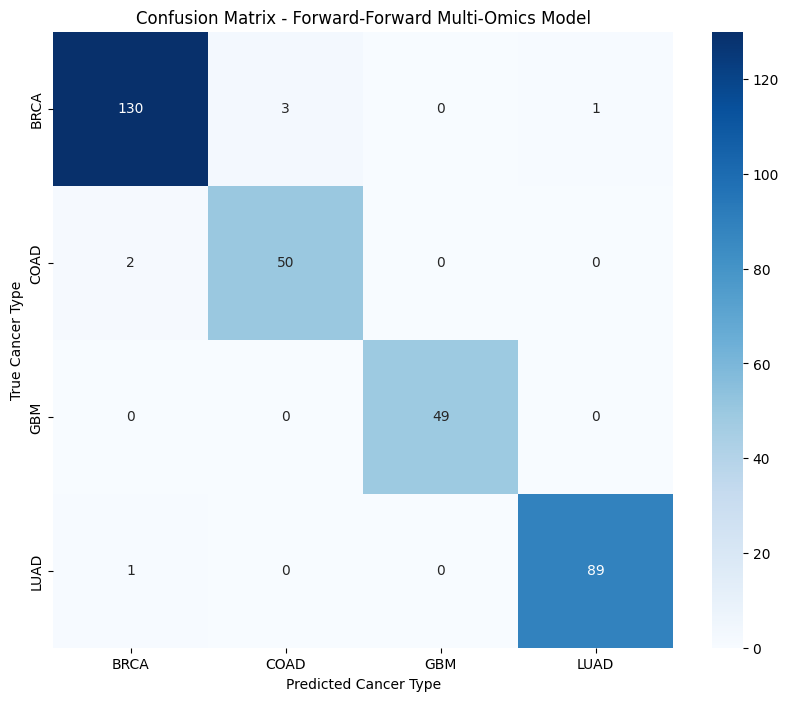

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

def comprehensive_evaluation(model, X_test, y_test):
    """Complete evaluation with all metrics"""

    model.eval()
    with torch.no_grad():
        predictions, omics_reprs, integrated = model(X_test)
        pred_labels = torch.argmax(predictions, dim=1)

    # Convert to numpy for sklearn metrics
    y_true = y_test.numpy()
    y_pred = pred_labels.numpy()

    cancer_names = ['BRCA', 'COAD', 'GBM', 'LUAD']

    print("🎯 COMPREHENSIVE PERFORMANCE EVALUATION")
    print("=" * 60)

    # Overall metrics
    overall_accuracy = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print(f"Macro F1-Score:   {macro_f1:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")

    # Detailed classification report
    print(f"\n DETAILED CLASSIFICATION REPORT:")
    report = classification_report(y_true, y_pred, target_names=cancer_names, digits=4)
    print(report)

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)

    print(f"\n PER-CANCER DETAILED METRICS:")
    for i, cancer in enumerate(cancer_names):
        print(f"{cancer}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall:    {recall[i]:.4f}")
        print(f"  F1-Score:  {f1[i]:.4f}")
        print(f"  Support:   {support[i]} patients")
        print()

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cancer_names, yticklabels=cancer_names)
    plt.title('Confusion Matrix - Forward-Forward Multi-Omics Model')
    plt.xlabel('Predicted Cancer Type')
    plt.ylabel('True Cancer Type')
    plt.show()

    # Calculate per-cancer accuracy from confusion matrix
    per_cancer_acc = {}
    for i, cancer in enumerate(cancer_names):
        if cm[i].sum() > 0:  # Avoid division by zero
            acc = cm[i, i] / cm[i].sum()
            per_cancer_acc[cancer] = acc

    return {
        'overall_accuracy': overall_accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'per_cancer_metrics': {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': per_cancer_acc
        },
        'confusion_matrix': cm,
        'predictions': y_pred,
        'probabilities': torch.softmax(predictions, dim=1).numpy()
    }

# Run comprehensive evaluation
ff_results = comprehensive_evaluation(trained_model_clean, X_test_clean, y_test_clean)


In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

def create_baseline_comparisons(X_clean_tensors, y_clean_tensor):
    """Compare with multiple baseline models"""

    # Combine all omics data for baseline models
    X_combined = torch.cat([X_clean_tensors['mRNA'],
                           X_clean_tensors['CNV'],
                           X_clean_tensors['Methy']], dim=1)

    # Train/test split (same as forward-forward)
    train_indices, test_indices = train_test_split(
        range(len(y_clean_tensor)), test_size=0.2, random_state=42,
        stratify=y_clean_tensor, shuffle=True
    )

    X_train = X_combined[train_indices].numpy()
    X_test = X_combined[test_indices].numpy()
    y_train = y_clean_tensor[train_indices].numpy()
    y_test = y_clean_tensor[test_indices].numpy()

    # Define baseline models
    baselines = {
        'Traditional MLP': MLPClassifier(
            hidden_layer_sizes=(256, 256, 128),
            max_iter=1000,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        ),
        'Support Vector Machine': SVC(
            kernel='rbf',
            C=1.0,
            random_state=42,
            probability=True
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42,
            multi_class='ovr'
        )
    }

    baseline_results = {}
    cancer_names = ['BRCA', 'COAD', 'GBM', 'LUAD']

    print(" TRAINING BASELINE MODELS FOR COMPARISON")
    print("=" * 50)

    for model_name, model in baselines.items():
        print(f"\nTraining {model_name}...")

        # Training time
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        weighted_f1 = f1_score(y_test, y_pred, average='weighted')

        # Per-cancer metrics
        precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

        baseline_results[model_name] = {
            'accuracy': accuracy,
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'per_cancer_f1': f1,
            'training_time': training_time,
            'predictions': y_pred,
            'probabilities': y_prob
        }

        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Macro F1: {macro_f1:.4f}")
        print(f"  Training time: {training_time:.2f}s")

    return baseline_results, X_test, y_test

# Run baseline comparisons
baseline_results, X_baseline_test, y_baseline_test = create_baseline_comparisons(X_clean_tensors, y_clean_tensor)


 TRAINING BASELINE MODELS FOR COMPARISON

Training Traditional MLP...
  Accuracy: 0.9415
  Macro F1: 0.9419
  Training time: 1.32s

Training Support Vector Machine...
  Accuracy: 0.9662
  Macro F1: 0.9622
  Training time: 1.99s

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Accuracy: 0.2892
  Macro F1: 0.3438
  Training time: 2.92s


In [28]:
def create_comparison_table(ff_results, baseline_results):
    """Create comprehensive comparison table"""

    import pandas as pd

    # Prepare data for comparison table
    comparison_data = []

    # Forward-Forward results
    comparison_data.append({
        'Model': 'Forward-Forward Multi-Omics',
        'Accuracy': ff_results['overall_accuracy'],
        'Macro F1': ff_results['macro_f1'],
        'Weighted F1': ff_results['weighted_f1'],
        'BRCA F1': ff_results['per_cancer_metrics']['f1'][0],
        'COAD F1': ff_results['per_cancer_metrics']['f1'][1],
        'GBM F1': ff_results['per_cancer_metrics']['f1'][2],
        'LUAD F1': ff_results['per_cancer_metrics']['f1'][3],

    })

    # Baseline results
    for model_name, results in baseline_results.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': results['accuracy'],
            'Macro F1': results['macro_f1'],
            'Weighted F1': results['weighted_f1'],
            'BRCA F1': results['per_cancer_f1'][0],
            'COAD F1': results['per_cancer_f1'][1],
            'GBM F1': results['per_cancer_f1'][2],
            'LUAD F1': results['per_cancer_f1'][3],
        })

    # Create DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

    print(" COMPREHENSIVE MODEL COMPARISON")
    print("=" * 80)
    print(comparison_df.round(4).to_string(index=False))

    # Performance improvements
    ff_accuracy = ff_results['overall_accuracy']
    best_baseline_acc = max([results['accuracy'] for results in baseline_results.values()])
    improvement = (ff_accuracy - best_baseline_acc) * 100

    print(f"\n PERFORMANCE ANALYSIS:")
    print(f"Forward-Forward Accuracy: {ff_accuracy:.4f}")
    print(f"Best Baseline Accuracy:   {best_baseline_acc:.4f}")
    print(f"Improvement:              +{improvement:.2f}%")

    return comparison_df

# Create comparison table
comparison_df = create_comparison_table(ff_results, baseline_results)


 COMPREHENSIVE MODEL COMPARISON
                      Model  Accuracy  Macro F1  Weighted F1  BRCA F1  COAD F1  GBM F1  LUAD F1
Forward-Forward Multi-Omics    0.9785    0.9788       0.9785   0.9738   0.9524     1.0   0.9889
     Support Vector Machine    0.9662    0.9622       0.9652   0.9606   0.8936     1.0   0.9944
            Traditional MLP    0.9415    0.9419       0.9410   0.9412   0.8866     1.0   0.9399
        Logistic Regression    0.2892    0.3438       0.2884   0.2657   0.0192     1.0   0.0904

 PERFORMANCE ANALYSIS:
Forward-Forward Accuracy: 0.9785
Best Baseline Accuracy:   0.9662
Improvement:              +1.23%
